# Prophet Demand Forecasting Tuning

This workflow loads the daily demand series, tunes Prophet hyperparameters across five configurations, evaluates each model on a holdout period, selects the best performer, and exports the best forecast.

In [1]:
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

warnings.filterwarnings("ignore")

print("Prophet tuning workflow initialized")

Prophet tuning workflow initialized


In [2]:
DATA_PATH = Path("../data/dataset_2_daily_demand_forecasting.csv.csv")
OUTPUT_PATH = Path("../outputs/demand_forecast.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(DATA_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="coerce")
raw_df = raw_df.dropna(subset=["Date"]).sort_values("Date")

series_df = (
    raw_df[["Date", "Total_Quantity"]]
    .rename(columns={"Date": "ds", "Total_Quantity": "y"})
    .set_index("ds")
    .resample("D")
    .sum()
    .reset_index()
)
series_df["y"] = series_df["y"].fillna(0).astype(float)
series_df = series_df.sort_values("ds").reset_index(drop=True)

series_df.head()

,ds,y
0,2009-12-01,26098.0
1,2009-12-02,31804.0
2,2009-12-03,49221.0
3,2009-12-04,21210.0
4,2009-12-05,5119.0


In [3]:
series_df.info()
series_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 739 entries, 0 to 738
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      739 non-null    datetime64[us]
 1   y       739 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.7 KB


,ds,y
count,739,739.000000
mean,2010-12-05 00:00:00,15162.581867
min,2009-12-01 00:00:00,0.000000
25%,2010-06-03 12:00:00,8122.500000
50%,2010-12-05 00:00:00,13980.000000
75%,2011-06-07 12:00:00,20499.000000
max,2011-12-09 00:00:00,125489.000000
std,NaN,13037.040684


In [4]:
def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calculate MAE, RMSE, and MAPE for a forecast."""
    mask = y_true != 0
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    return {"mae": float(mae), "rmse": rmse, "mape": mape}


n_test = max(30, int(len(series_df) * 0.2))
split_index = len(series_df) - n_test
train = series_df.iloc[:split_index].copy()
test = series_df.iloc[split_index:].copy()

print(f"Training rows: {len(train)}")
print(f"Test rows: {len(test)}")

Training rows: 592
Test rows: 147


In [5]:
from prophet import Prophet
import pandas as pd
import numpy as np

In [6]:
print(train.columns)
print(test.columns)

Index(['ds', 'y'], dtype='str')
Index(['ds', 'y'], dtype='str')


In [7]:
model_configs = [
    {"name": "baseline", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 10.0},
    {"name": "flexible", "changepoint_prior_scale": 0.10, "seasonality_prior_scale": 10.0},
    {"name": "smooth", "changepoint_prior_scale": 0.05, "seasonality_prior_scale": 20.0},
    {"name": "aggressive", "changepoint_prior_scale": 0.20, "seasonality_prior_scale": 15.0},
    {"name": "balanced", "changepoint_prior_scale": 0.08, "seasonality_prior_scale": 12.0},
]

results = []

for config in model_configs:
    model = Prophet(
        changepoint_prior_scale=config["changepoint_prior_scale"],
        seasonality_prior_scale=config["seasonality_prior_scale"],
        yearly_seasonality=True,
        weekly_seasonality=True,
        interval_width=0.95,
    )

    model.add_seasonality(
        name="monthly",
        period=30.5,
        fourier_order=5,
    )

    model.fit(train)

    future = model.make_future_dataframe(periods=len(test), freq="D")
    forecast = model.predict(future)

    evaluation_df = test.merge(
        forecast[["ds", "yhat"]],
        on="ds",
        how="inner"
    )

    metrics = calculate_metrics(
        evaluation_df["y"].to_numpy(),
        evaluation_df["yhat"].to_numpy()
    )

    row = {
        "model": config["name"],
        "changepoint_prior_scale": config["changepoint_prior_scale"],
        "seasonality_prior_scale": config["seasonality_prior_scale"],
        "mae": metrics["mae"],
        "rmse": metrics["rmse"],
        "mape": metrics["mape"],
    }

    results.append(row)

    print(
        f"{config['name']} --> "
        f"MAE: {metrics['mae']:.2f}, "
        f"RMSE: {metrics['rmse']:.2f}, "
        f"MAPE: {metrics['mape']:.2f}%"
    )

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(["mape", "rmse", "mae"], ascending=[True, True, True]).reset_index(drop=True)
comparison_df

21:55:27 - cmdstanpy - INFO - Chain [1] start processing
21:55:27 - cmdstanpy - INFO - Chain [1] done processing
21:55:28 - cmdstanpy - INFO - Chain [1] start processing
21:55:28 - cmdstanpy - INFO - Chain [1] done processing


baseline --> MAE: 6939.38, RMSE: 10325.50, MAPE: 33.81%


21:55:28 - cmdstanpy - INFO - Chain [1] start processing
21:55:28 - cmdstanpy - INFO - Chain [1] done processing


flexible --> MAE: 6931.52, RMSE: 10315.30, MAPE: 33.83%


21:55:28 - cmdstanpy - INFO - Chain [1] start processing
21:55:28 - cmdstanpy - INFO - Chain [1] done processing


smooth --> MAE: 6945.99, RMSE: 10337.28, MAPE: 33.82%


21:55:28 - cmdstanpy - INFO - Chain [1] start processing
21:55:29 - cmdstanpy - INFO - Chain [1] done processing


aggressive --> MAE: 6816.94, RMSE: 10022.51, MAPE: 34.64%
balanced --> MAE: 6926.53, RMSE: 10304.59, MAPE: 33.82%


,model,changepoint_prior_scale,seasonality_prior_scale,mae,rmse,mape
0,baseline,0.05,10.0,6939.375394,10325.500990,33.811195
1,smooth,0.05,20.0,6945.991867,10337.275726,33.817158
2,balanced,0.08,12.0,6926.527542,10304.591897,33.823301
3,flexible,0.10,10.0,6931.516467,10315.297927,33.830511
4,aggressive,0.20,15.0,6816.936702,10022.509753,34.635579


In [8]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(["mape", "rmse", "mae"], ascending=[True, True, True]).reset_index(drop=True)
comparison_df

,model,changepoint_prior_scale,seasonality_prior_scale,mae,rmse,mape
0,baseline,0.05,10.0,6939.375394,10325.500990,33.811195
1,smooth,0.05,20.0,6945.991867,10337.275726,33.817158
2,balanced,0.08,12.0,6926.527542,10304.591897,33.823301
3,flexible,0.10,10.0,6931.516467,10315.297927,33.830511
4,aggressive,0.20,15.0,6816.936702,10022.509753,34.635579


In [9]:
best_config = comparison_df.iloc[0].to_dict()
best_model_name = best_config["model"]

print(f"Best model: {best_model_name}")
print(f"MAE: {best_config['mae']:.2f}")
print(f"RMSE: {best_config['rmse']:.2f}")
print(f"MAPE: {best_config['mape']:.2f}%")

best_model = Prophet(
    changepoint_prior_scale=best_config["changepoint_prior_scale"],
    seasonality_prior_scale=best_config["seasonality_prior_scale"],
    yearly_seasonality=True,
    weekly_seasonality=True,
    interval_width=0.95,
)
best_model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)
best_model.fit(series_df)

future = best_model.make_future_dataframe(periods=30, freq="D")
best_forecast = best_model.predict(future)

best_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

21:55:29 - cmdstanpy - INFO - Chain [1] start processing


Best model: baseline
MAE: 6939.38
RMSE: 10325.50
MAPE: 33.81%


21:55:29 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
764,2012-01-04,11179.805039,-8440.392427,30897.819446
765,2012-01-05,15555.072580,-3539.344767,34612.923112
766,2012-01-06,10120.855111,-7901.444486,27981.134464
767,2012-01-07,-4691.359323,-22873.101215,13809.291234
768,2012-01-08,6768.848593,-11000.748332,25945.607301


In [10]:
best_forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(OUTPUT_PATH, index=False)
print(f"Best forecast saved to {OUTPUT_PATH}")

Best forecast saved to ..\outputs\demand_forecast.csv


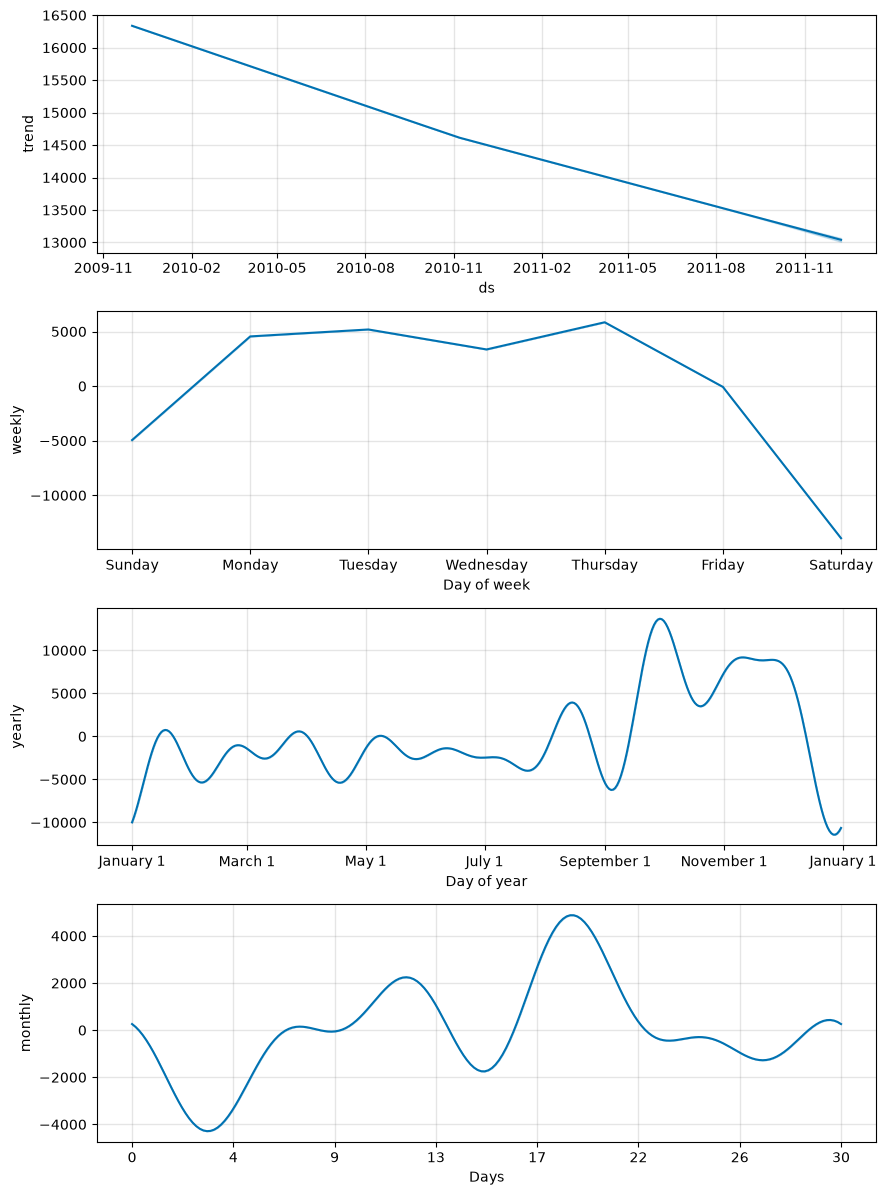

In [11]:
fig2 = model.plot_components(forecast)

In [12]:
print(test.head())

            ds        y
592 2011-07-16      0.0
593 2011-07-17  11019.0
594 2011-07-18  15098.0
595 2011-07-19  29168.0
596 2011-07-20  17676.0


In [13]:
print(forecast[['ds','yhat']].head())

          ds          yhat
0 2009-12-01  26839.785754
1 2009-12-02  26545.243962
2 2009-12-03  29922.161352
3 2009-12-04  23794.821273
4 2009-12-05   9252.704173


In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mape = mean_absolute_percentage_error(
    y_true,
    y_pred
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 3.970951245115525e+20 %


In [15]:
print((test['y'] == 0).sum())
print(test['y'].min())

22
0.0


In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mask = y_true != 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_pred[mask])
        / y_true[mask]
    )
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 33.82 %


In [17]:
df = pd.read_csv("../data/dataset_2_daily_demand_forecasting.csv.csv")

In [18]:
print(df.columns.tolist())

['Date', 'Total_Quantity', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Year', 'Month', 'Week_Of_Year', 'Day_Of_Week', 'Is_Weekend']


In [19]:
ts = df[["Date", "Total_Quantity"]].copy()

ts["Date"] = pd.to_datetime(ts["Date"])

ts.rename(
    columns={
        "Date": "ds",
        "Total_Quantity": "y"
    },
    inplace=True
)

ts = ts.sort_values("ds").reset_index(drop=True)

ts.head()

,ds,y
0,2009-12-01,26098.0
1,2009-12-02,31804.0
2,2009-12-03,49221.0
3,2009-12-04,21210.0
4,2009-12-05,5119.0


In [20]:
print(ts.head())

print(ts.columns)

print(ts.shape)

          ds        y
0 2009-12-01  26098.0
1 2009-12-02  31804.0
2 2009-12-03  49221.0
3 2009-12-04  21210.0
4 2009-12-05   5119.0
Index(['ds', 'y'], dtype='str')
(739, 2)


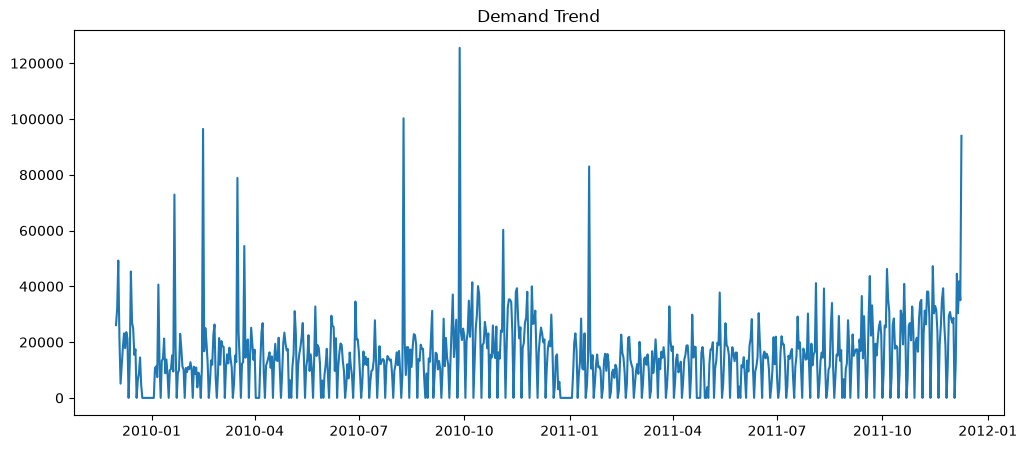

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(ts['ds'], ts['y'])
plt.title("Demand Trend")
plt.show()

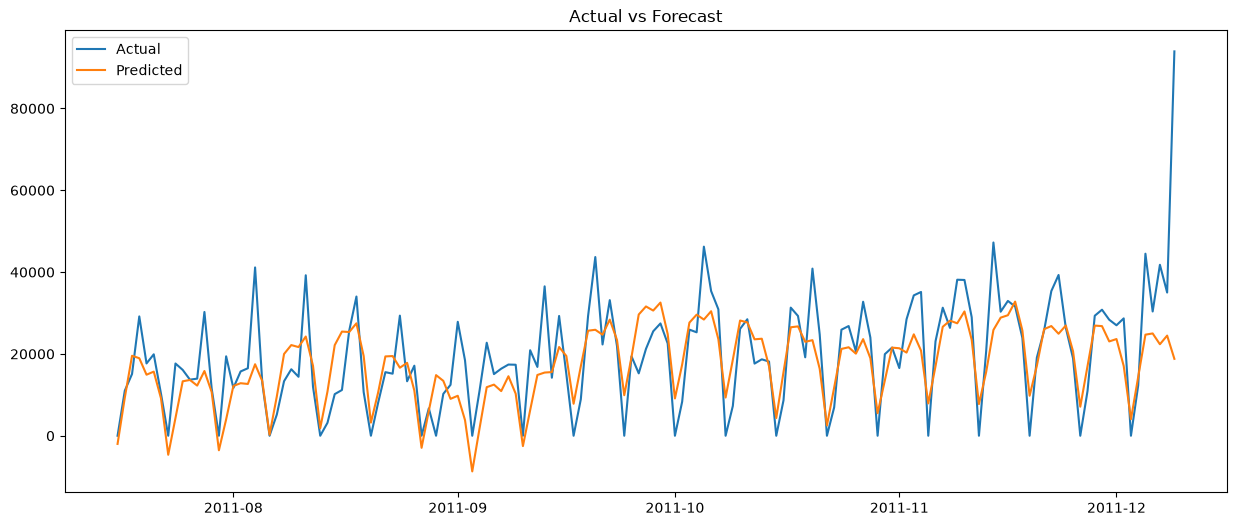

In [22]:
forecast_test = forecast.tail(len(test))

plt.figure(figsize=(15,6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Forecast")

plt.show()

In [23]:
ts["y"].describe()

count       739.000000
mean      15162.581867
std       13037.040684
min           0.000000
25%        8122.500000
50%       13980.000000
75%       20499.000000
max      125489.000000
Name: y, dtype: float64

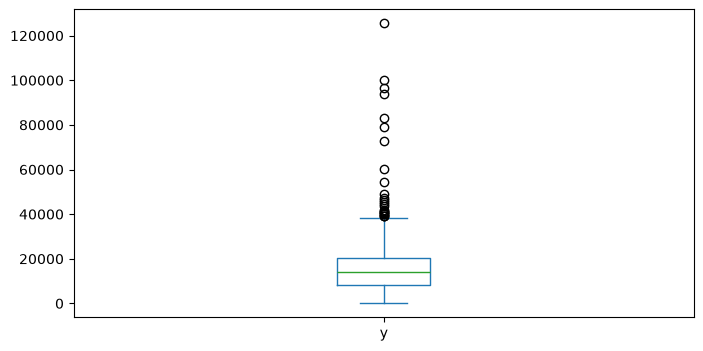

In [24]:
ts["y"].plot(
    kind="box",
    figsize=(8,4)
)
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

forecast_test = forecast.tail(len(test))

y_true = test['y'].values
y_pred = forecast_test['yhat'].values

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

mask = y_true != 0

mape = np.mean(
    np.abs(
        (y_true[mask] - y_pred[mask])
        / y_true[mask]
    )
) * 100

print("MAE :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("MAPE :", round(mape, 2), "%")

MAE : 6926.53
RMSE : 10304.59
MAPE : 33.82 %


In [26]:
actual = evaluation_df["y"]
predicted = evaluation_df["yhat"]

In [27]:
print(len(actual))
print(len(predicted))

print(actual.head())
print(predicted.head())

147
147
0        0.0
1    11019.0
2    15098.0
3    29168.0
4    17676.0
Name: y, dtype: float64
0    -1997.776777
1     9313.177944
2    19550.729041
3    18953.224145
4    14921.946687
Name: yhat, dtype: float64


In [28]:
print(type(actual))
print(type(predicted))

<class 'pandas.Series'>
<class 'pandas.Series'>


In [29]:
print(actual[:10])
print(predicted[:10])

0        0.0
1    11019.0
2    15098.0
3    29168.0
4    17676.0
5    19907.0
6    10270.0
7        0.0
8    17661.0
9    16095.0
Name: y, dtype: float64
0    -1997.776777
1     9313.177944
2    19550.729041
3    18953.224145
4    14921.946687
5    15671.895245
6     9140.623773
7    -4646.552082
8     4271.480304
9    13311.069027
Name: yhat, dtype: float64


In [30]:
print("Actual Min:", actual.min())
print("Actual Max:", actual.max())

print("Predicted Min:", predicted.min())
print("Predicted Max:", predicted.max())

Actual Min: 0.0
Actual Max: 93950.0
Predicted Min: -8710.474692757873
Predicted Max: 32792.53661209233


In [31]:
print("Zero values in actual:")
print((actual == 0).sum())

Zero values in actual:
22


In [32]:
non_zero_mask = actual != 0

actual_non_zero = actual[non_zero_mask]
predicted_non_zero = predicted[non_zero_mask]

mape = np.mean(
    np.abs(
        (actual_non_zero - predicted_non_zero)
        / actual_non_zero
    )
) * 100

print(f"Corrected MAPE : {mape:.2f}%")

Corrected MAPE : 33.82%


In [33]:
forecast_output = pd.DataFrame({
    "Date": test["ds"].values,
    "Actual": actual,
    "Predicted": predicted
})

forecast_output.to_csv(
    "../outputs/demand_forecast.csv",
    index=False
)

print("Forecast exported successfully")

Forecast exported successfully


In [34]:
print(type(actual))
print(type(predicted))

print("Actual Min:", actual.min())
print("Actual Max:", actual.max())

print("Predicted Min:", predicted.min())
print("Predicted Max:", predicted.max())

print((actual == 0).sum())

<class 'pandas.Series'>
<class 'pandas.Series'>
Actual Min: 0.0
Actual Max: 93950.0
Predicted Min: -8710.474692757873
Predicted Max: 32792.53661209233
22


In [35]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2009-12-01,26839.785754,9224.535310,44936.548791
1,2009-12-02,26545.243962,9387.292594,45446.267823
2,2009-12-03,29922.161352,12173.120852,47589.094562
3,2009-12-04,23794.821273,6516.062465,42540.708650
4,2009-12-05,9252.704173,-9598.823568,27857.110201


In [36]:
forecast_output = forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
]

forecast_output.to_csv(
    '../outputs/demand_forecast.csv',
    index=False
)

print("Forecast Exported")

Forecast Exported


In [37]:
import itertools
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

changepoint_prior_scales = [0.01, 0.03, 0.05, 0.08, 0.10, 0.20]
seasonality_prior_scales = [5, 10, 15, 20]
seasonality_modes = ["additive", "multiplicative"]

results = []

total_configs = (
    len(changepoint_prior_scales)
    * len(seasonality_prior_scales)
    * len(seasonality_modes)
)

config_count = 0

for cps, sps, sm in itertools.product(
    changepoint_prior_scales,
    seasonality_prior_scales,
    seasonality_modes,
):

    config_count += 1

    print(
        f"Training {config_count}/{total_configs} | "
        f"CPS={cps} SPS={sps} MODE={sm}"
    )

    model = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps,
        seasonality_mode=sm,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        interval_width=0.95,
    )

    model.add_seasonality(
        name="monthly",
        period=30.5,
        fourier_order=5,
    )

    model.fit(train)

    future = test[["ds"]].copy()

    forecast = model.predict(future)

    evaluation_df = test.merge(
        forecast[
            [
                "ds",
                "yhat",
                "yhat_lower",
                "yhat_upper",
            ]
        ],
        on="ds",
        how="left",
    )

    metrics = calculate_metrics(
        evaluation_df["y"].to_numpy(),
        evaluation_df["yhat"].to_numpy(),
    )

    results.append(
        {
            "changepoint_prior_scale": cps,
            "seasonality_prior_scale": sps,
            "seasonality_mode": sm,
            "MAE": metrics["mae"],
            "RMSE": metrics["rmse"],
            "MAPE": metrics["mape"],
        }
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("MAPE")
    .reset_index(drop=True)
)

print("\n")
print("=" * 80)
print("TOP 10 MODELS")
print("=" * 80)

display(results_df.head(10))

best_row = results_df.iloc[0]

print("\nBEST PARAMETERS")
print(best_row)

print("\n")
print(f"Best MAE  : {best_row['MAE']:.2f}")
print(f"Best RMSE : {best_row['RMSE']:.2f}")
print(f"Best MAPE : {best_row['MAPE']:.2f}%")

Training 1/48 | CPS=0.01 SPS=5 MODE=additive


21:55:31 - cmdstanpy - INFO - Chain [1] start processing
21:55:31 - cmdstanpy - INFO - Chain [1] done processing
21:55:31 - cmdstanpy - INFO - Chain [1] start processing


Training 2/48 | CPS=0.01 SPS=5 MODE=multiplicative


21:55:31 - cmdstanpy - INFO - Chain [1] done processing
21:55:31 - cmdstanpy - INFO - Chain [1] start processing
21:55:31 - cmdstanpy - INFO - Chain [1] done processing


Training 3/48 | CPS=0.01 SPS=10 MODE=additive


...

Training 47/48 | CPS=0.2 SPS=20 MODE=additive


21:55:42 - cmdstanpy - INFO - Chain [1] start processing
21:55:42 - cmdstanpy - INFO - Chain [1] done processing


Training 48/48 | CPS=0.2 SPS=20 MODE=multiplicative


TOP 10 MODELS


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,MAE,RMSE,MAPE
0,0.20,5,multiplicative,6889.717634,10374.663964,32.818679
1,0.20,15,multiplicative,6931.264926,10432.266305,32.851426
2,0.20,10,multiplicative,6933.538314,10433.037422,32.859211
3,0.20,20,multiplicative,6804.529554,10211.607720,32.867366
4,0.01,20,multiplicative,7109.277002,10612.115270,33.041212
5,0.01,15,multiplicative,7139.756925,10649.676098,33.081237
6,0.01,10,multiplicative,7192.655833,10713.569830,33.158791
7,0.01,5,multiplicative,7175.534854,10678.132202,33.168947
8,0.03,10,multiplicative,7155.382546,10676.286246,33.378932
9,0.03,15,multiplicative,7060.543744,10545.559365,33.401364



BEST PARAMETERS
changepoint_prior_scale               0.2
seasonality_prior_scale                 5
seasonality_mode           multiplicative
MAE                           6889.717634
RMSE                         10374.663964
MAPE                            32.818679
Name: 0, dtype: object


Best MAE  : 6889.72
Best RMSE : 10374.66
Best MAPE : 32.82%


In [38]:
Q1 = train["y"].quantile(0.25)
Q3 = train["y"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

print(train[(train["y"] < lower) | (train["y"] > upper)].shape)

-9698.75
35599.25
(20, 2)


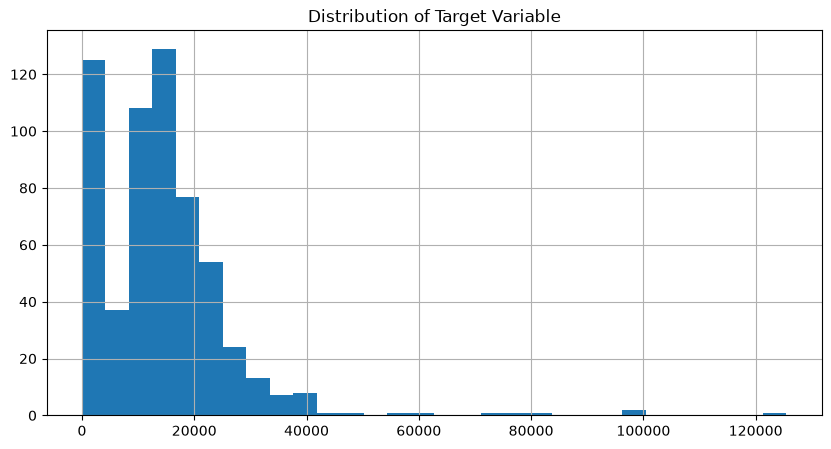

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
train["y"].hist(bins=30)
plt.title("Distribution of Target Variable")
plt.show()

In [40]:
corr_cols = [
    "Total_Quantity",
    "Rolling_7_Day_Demand",
    "Rolling_30_Day_Demand",
    "Invoice_Count",
    "SKU_Count",
    "Is_Weekend",
]

print(df[corr_cols].corr()["Total_Quantity"].sort_values(ascending=False))

Total_Quantity           1.000000
Invoice_Count            0.699389
SKU_Count                0.675396
Rolling_7_Day_Demand     0.482577
Rolling_30_Day_Demand    0.359066
Is_Weekend              -0.495519
Name: Total_Quantity, dtype: float64


In [41]:
print(train["ds"].dtype)
print(df["Date"].dtype)

datetime64[us]
str


In [42]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[us]


In [43]:
train["ds"] = pd.to_datetime(train["ds"]).dt.normalize()
test["ds"] = pd.to_datetime(test["ds"]).dt.normalize()
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()

In [44]:
df["Date"] = pd.to_datetime(df["Date"])

train_reg = train.merge(
    df[
        [
            "Date",
            "Invoice_Count",
            "SKU_Count",
            "Rolling_7_Day_Demand",
            "Rolling_30_Day_Demand",
            "Is_Weekend",
        ]
    ],
    left_on="ds",
    right_on="Date",
    how="left",
).drop(columns=["Date"])

test_reg = test.merge(
    df[
        [
            "Date",
            "Invoice_Count",
            "SKU_Count",
            "Rolling_7_Day_Demand",
            "Rolling_30_Day_Demand",
            "Is_Weekend",
        ]
    ],
    left_on="ds",
    right_on="Date",
    how="left",
).drop(columns=["Date"])

In [45]:
print(train_reg.isna().sum())
print(test_reg.isna().sum())

ds                       0
y                        0
Invoice_Count            0
SKU_Count                0
Rolling_7_Day_Demand     0
Rolling_30_Day_Demand    0
Is_Weekend               0
dtype: int64
ds                       0
y                        0
Invoice_Count            0
SKU_Count                0
Rolling_7_Day_Demand     0
Rolling_30_Day_Demand    0
Is_Weekend               0
dtype: int64


In [46]:
model = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
)

model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)

model.add_regressor("Invoice_Count")
model.add_regressor("SKU_Count")
model.add_regressor("Rolling_7_Day_Demand")
model.add_regressor("Is_Weekend")

In [47]:
model.fit(train_reg)

21:55:43 - cmdstanpy - INFO - Chain [1] start processing
21:55:43 - cmdstanpy - INFO - Chain [1] done processing


In [48]:
future = test_reg.drop(columns=["y"]).copy()

forecast = model.predict(future)

In [49]:
evaluation_df = test_reg.merge(
    forecast[
        [
            "ds",
            "yhat",
        ]
    ],
    on="ds",
    how="left",
)

In [50]:
metrics = calculate_metrics(
    evaluation_df["y"].to_numpy(),
    evaluation_df["yhat"].to_numpy(),
)

print(metrics)

{'mae': 5226.048394274238, 'rmse': 8428.950630867002, 'mape': 25.714759037020908}


In [51]:
print("MAE :", round(metrics["mae"],2))
print("RMSE:", round(metrics["rmse"],2))
print("MAPE:", round(metrics["mape"],2),"%")

MAE : 5226.05
RMSE: 8428.95
MAPE: 25.71 %


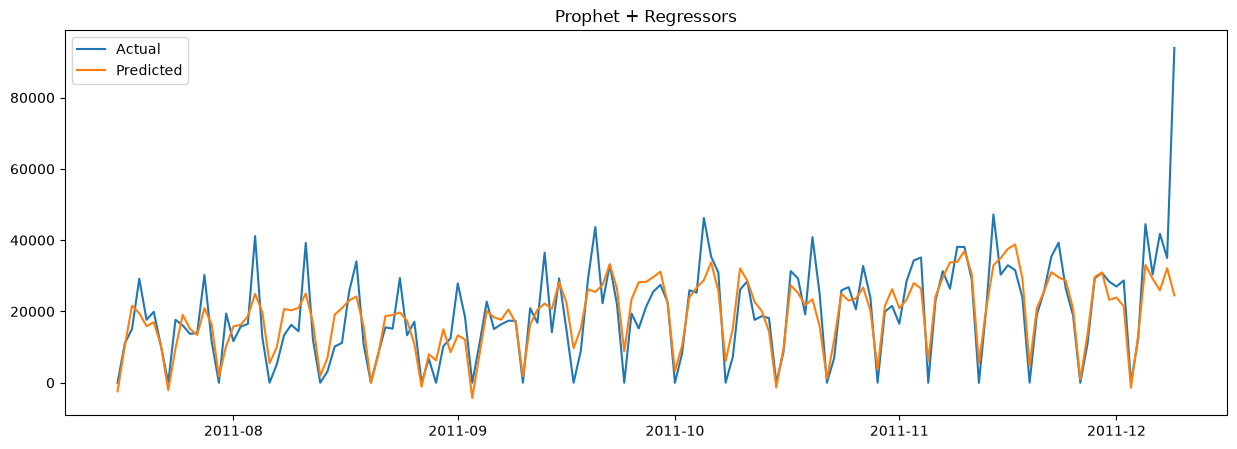

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["y"],
    label="Actual"
)

plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Predicted"
)

plt.legend()
plt.title("Prophet + Regressors")

plt.show()

In [53]:
forecast_output = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper",
    ]
].copy()

forecast_output.columns = [
    "Date",
    "Predicted_Demand",
    "Lower_Bound",
    "Upper_Bound",
]

forecast_output.to_csv(
    "../outputs/demand_forecast.csv",
    index=False,
)

print("Final demand_forecast.csv saved.")

Final demand_forecast.csv saved.


In [54]:
print(train.shape)
print(test.shape)

(592, 2)
(147, 2)


In [55]:
print(train.columns.tolist())
print(test.columns.tolist())

['ds', 'y']
['ds', 'y']


In [56]:
print(df.columns.tolist())

['Date', 'Total_Quantity', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Year', 'Month', 'Week_Of_Year', 'Day_Of_Week', 'Is_Weekend']


In [57]:
df["Date"] = pd.to_datetime(df["Date"])

train_reg = train.merge(
    df[
        [
            "Date",
            "Invoice_Count",
            "SKU_Count",
            "Rolling_7_Day_Demand",
            "Is_Weekend",
        ]
    ],
    left_on="ds",
    right_on="Date",
    how="left",
).drop(columns=["Date"])

test_reg = test.merge(
    df[
        [
            "Date",
            "Invoice_Count",
            "SKU_Count",
            "Rolling_7_Day_Demand",
            "Is_Weekend",
        ]
    ],
    left_on="ds",
    right_on="Date",
    how="left",
).drop(columns=["Date"])

In [58]:
print(train_reg.columns)
print(test_reg.columns)

Index(['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand',
       'Is_Weekend'],
      dtype='str')
Index(['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand',
       'Is_Weekend'],
      dtype='str')


In [59]:
print(train_reg.isna().sum())

print(test_reg.isna().sum())

ds                      0
y                       0
Invoice_Count           0
SKU_Count               0
Rolling_7_Day_Demand    0
Is_Weekend              0
dtype: int64
ds                      0
y                       0
Invoice_Count           0
SKU_Count               0
Rolling_7_Day_Demand    0
Is_Weekend              0
dtype: int64


In [60]:
model = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)

for reg in [
    "Invoice_Count",
    "SKU_Count",
    "Rolling_7_Day_Demand",
    "Is_Weekend",
]:
    model.add_regressor(reg)

model.fit(train_reg)

21:55:43 - cmdstanpy - INFO - Chain [1] start processing
21:55:43 - cmdstanpy - INFO - Chain [1] done processing


In [61]:
future = test_reg.drop(columns=["y"])

forecast = model.predict(future)

evaluation_df = test_reg.merge(
    forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper",
        ]
    ],
    on="ds",
    how="left",
)

In [62]:
metrics = calculate_metrics(
    evaluation_df["y"],
    evaluation_df["yhat"],
)

print(metrics)

{'mae': 5226.048394274238, 'rmse': 8428.950630867002, 'mape': 25.714759037020908}


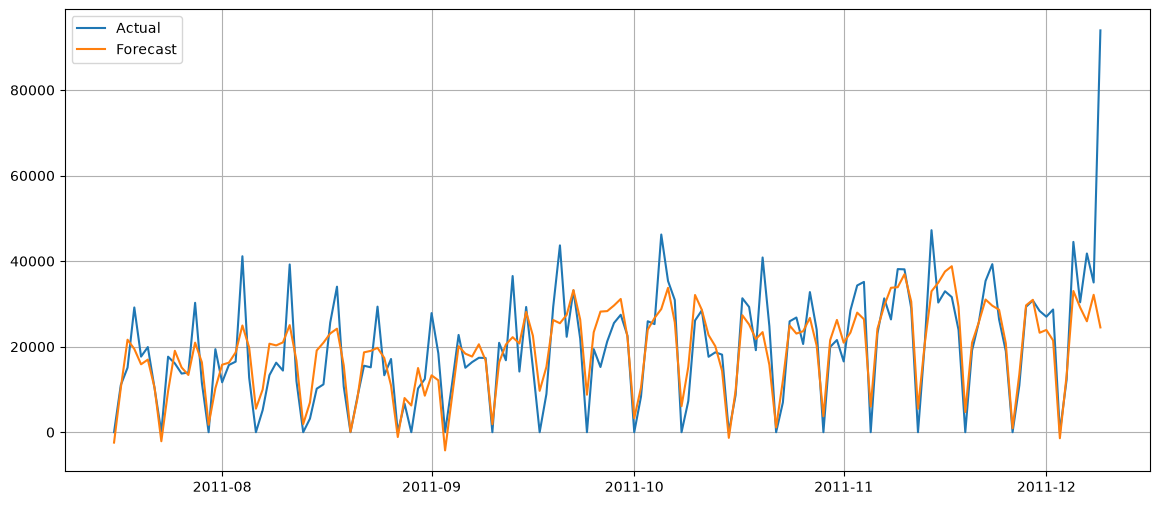

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    evaluation_df["ds"],
    evaluation_df["y"],
    label="Actual",
)

plt.plot(
    evaluation_df["ds"],
    evaluation_df["yhat"],
    label="Forecast",
)

plt.legend()

plt.grid(True)

plt.show()

In [64]:
print(df["Rolling_30_Day_Demand"].corr(df["Total_Quantity"]))

0.35906632091931234


In [65]:
model = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

In [66]:
model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)

In [67]:
for reg in [
    "Invoice_Count",
    "SKU_Count",
    "Rolling_7_Day_Demand",
    "Rolling_30_Day_Demand",
    "Is_Weekend",
]:
    model.add_regressor(reg)

In [68]:
print(train_reg.columns)

Index(['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand',
       'Is_Weekend'],
      dtype='str')


In [69]:
print(train_reg.columns.tolist())
print(test_reg.columns.tolist())

['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Is_Weekend']
['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Is_Weekend']


In [70]:
print(train_reg.columns)
print(test_reg.columns)

print(train_reg.isna().sum())
print(test_reg.isna().sum())

Index(['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand',
       'Is_Weekend'],
      dtype='str')
Index(['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand',
       'Is_Weekend'],
      dtype='str')
ds                      0
y                       0
Invoice_Count           0
SKU_Count               0
Rolling_7_Day_Demand    0
Is_Weekend              0
dtype: int64
ds                      0
y                       0
Invoice_Count           0
SKU_Count               0
Rolling_7_Day_Demand    0
Is_Weekend              0
dtype: int64


In [71]:
model = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
)

model.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5,
)

for reg in [
    "Invoice_Count",
    "SKU_Count",
    "Rolling_7_Day_Demand",
    "Rolling_30_Day_Demand",
    "Is_Weekend",
]:
    model.add_regressor(reg)

In [72]:
metrics = calculate_metrics(
    evaluation_df["y"],
    evaluation_df["yhat"],
)

print(metrics)

{'mae': 5226.048394274238, 'rmse': 8428.950630867002, 'mape': 25.714759037020908}


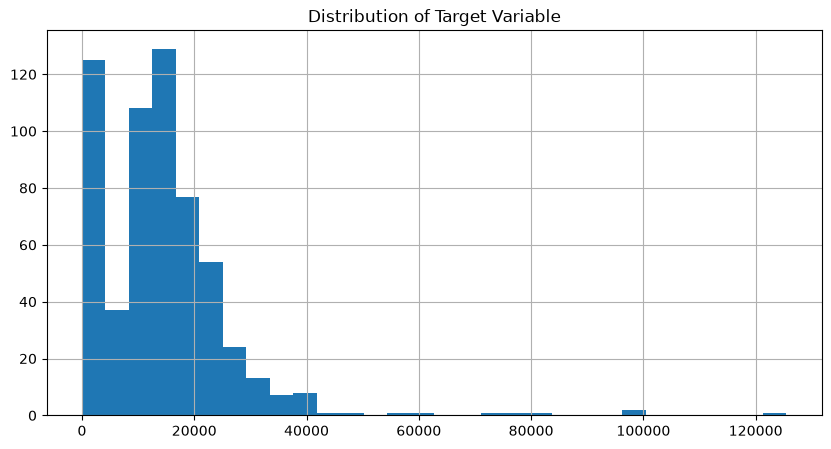

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
train["y"].hist(bins=30)
plt.title("Distribution of Target Variable")
plt.show()

In [74]:
# ── CELL A: Imports & Config ──
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

DATA_PATH = Path("../data/dataset_2_daily_demand_forecasting.csv.csv")
OUTPUT_PATH = Path("../outputs/demand_forecast_v2.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
print("✅ Imports done")

✅ Imports done


In [75]:
# ── CELL B: Load Raw Data ──
raw_df = pd.read_csv(DATA_PATH)
raw_df["Date"] = pd.to_datetime(raw_df["Date"], errors="coerce")
raw_df = raw_df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
print(f"Raw rows: {len(raw_df)}")
print(f"Columns : {raw_df.columns.tolist()}")

Raw rows: 739
Columns : ['Date', 'Total_Quantity', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Year', 'Month', 'Week_Of_Year', 'Day_Of_Week', 'Is_Weekend']


In [76]:
# ── CELL C: Series + All 5 Regressors (Rolling_30_Day_Demand FIX) ──
REGRESSOR_COLS = [
    "Invoice_Count",
    "SKU_Count",
    "Rolling_7_Day_Demand",
    "Rolling_30_Day_Demand",   # ← ye tumhare purane cells mein MISSING tha
    "Is_Weekend",
]

series_df = (
    raw_df[["Date", "Total_Quantity"]]
    .rename(columns={"Date": "ds", "Total_Quantity": "y"})
    .set_index("ds")
    .resample("D")
    .sum()
    .reset_index()
)
series_df["y"] = series_df["y"].fillna(0).astype(float)
series_df = series_df.sort_values("ds").reset_index(drop=True)

raw_daily = raw_df.copy()
raw_daily["Date"] = pd.to_datetime(raw_daily["Date"]).dt.normalize()
reg_daily = (
    raw_daily[["Date"] + REGRESSOR_COLS]
    .groupby("Date")
    .first()
    .reset_index()
    .rename(columns={"Date": "ds"})
)

series_df["ds"] = pd.to_datetime(series_df["ds"]).dt.normalize()
reg_daily["ds"] = pd.to_datetime(reg_daily["ds"]).dt.normalize()

full_df = series_df.merge(reg_daily, on="ds", how="left")
full_df[REGRESSOR_COLS] = full_df[REGRESSOR_COLS].ffill().bfill()

print(f"Shape   : {full_df.shape}")
print(f"Columns : {full_df.columns.tolist()}")
print(f"NaN check:\n{full_df.isna().sum()}")

Shape   : (739, 7)
Columns : ['ds', 'y', 'Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Is_Weekend']
NaN check:
ds                       0
y                        0
Invoice_Count            0
SKU_Count                0
Rolling_7_Day_Demand     0
Rolling_30_Day_Demand    0
Is_Weekend               0
dtype: int64


In [77]:
# ── CELL D: Train/Test Split ──
n_test    = max(30, int(len(full_df) * 0.2))
split_idx = len(full_df) - n_test

train_raw = full_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df   = full_df.iloc[split_idx:].copy().reset_index(drop=True)

print(f"Train rows : {len(train_raw)}")
print(f"Test rows  : {len(test_df)}")
print(f"Test range : {test_df['ds'].min().date()} → {test_df['ds'].max().date()}")

Train rows : 592
Test rows  : 147
Test range : 2011-07-16 → 2011-12-09


In [78]:
# ── CELL E: Preprocessing — Outlier Cap + Zero Removal (TRAIN ONLY) ──
y_cap = train_raw["y"].quantile(0.99)
print(f"99th pct cap : {y_cap:,.0f}")
print(f"Rows above cap : {(train_raw['y'] > y_cap).sum()}")

train_capped = train_raw.copy()
train_capped["y"] = train_capped["y"].clip(upper=y_cap)

train_clean = train_capped[train_capped["y"] > 0].reset_index(drop=True)
print(f"Train after cap+zero removal : {len(train_clean)} rows")
print(train_clean["y"].describe())

99th pct cap : 61,406
Rows above cap : 6
Train after cap+zero removal : 479 rows
count      479.000000
mean     16940.118455
std       9418.716862
min       2036.000000
25%      11107.000000
50%      15011.000000
75%      20307.500000
max      61405.790000
Name: y, dtype: float64


In [79]:
# ── CELL F: Canonical calculate_metrics ──
def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mask = y_true != 0
    mape = float(np.mean(np.abs(
        (y_true[mask] - y_pred[mask]) / y_true[mask]
    )) * 100) if mask.any() else None
    return {"mae": mae, "rmse": rmse, "mape": mape}

print("✅ calculate_metrics ready")

✅ calculate_metrics ready


In [80]:
# ── CELL G: Train Prophet Model ──
model = Prophet(
    changepoint_prior_scale=0.01,
    seasonality_prior_scale=15,
    seasonality_mode="multiplicative",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,
)
model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
for reg in REGRESSOR_COLS:
    model.add_regressor(reg)

fit_cols = ["ds", "y"] + REGRESSOR_COLS
model.fit(train_clean[fit_cols])
print("✅ Model trained")
print(f"Regressors: {list(model.extra_regressors.keys())}")

21:55:44 - cmdstanpy - INFO - Chain [1] start processing
21:55:44 - cmdstanpy - INFO - Chain [1] done processing


✅ Model trained
Regressors: ['Invoice_Count', 'SKU_Count', 'Rolling_7_Day_Demand', 'Rolling_30_Day_Demand', 'Is_Weekend']


In [81]:
# ── CELL H: Predict on Test (Direct — No Leakage) ──
test_input = test_df[["ds"] + REGRESSOR_COLS].copy()
forecast   = model.predict(test_input)

evaluation_df = test_df[["ds", "y"]].merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds", how="left"
)
print(evaluation_df[["ds", "y", "yhat"]].head())

          ds        y          yhat
0 2011-07-16      0.0   4420.055797
1 2011-07-17  11019.0  10745.886573
2 2011-07-18  15098.0  19809.633072
3 2011-07-19  29168.0  19324.309832
4 2011-07-20  17676.0  15270.014984


In [82]:
# ── CELL I: Final Metrics ──
metrics = calculate_metrics(
    evaluation_df["y"].to_numpy(),
    evaluation_df["yhat"].to_numpy(),
)
print("=" * 45)
print(f"  MAE  : {metrics['mae']:>10,.2f}")
print(f"  RMSE : {metrics['rmse']:>10,.2f}")
print(f"  MAPE : {metrics['mape']:>10.2f}%")
print("=" * 45)
print(f"  Old MAPE  : 25.71%")
print(f"  New MAPE  : {metrics['mape']:.2f}%")
print(f"  Improvement: {25.71 - metrics['mape']:.2f} points")

  MAE  :   5,534.49
  RMSE :   8,759.64
  MAPE :      22.53%
  Old MAPE  : 25.71%
  New MAPE  : 22.53%
  Improvement: 3.18 points


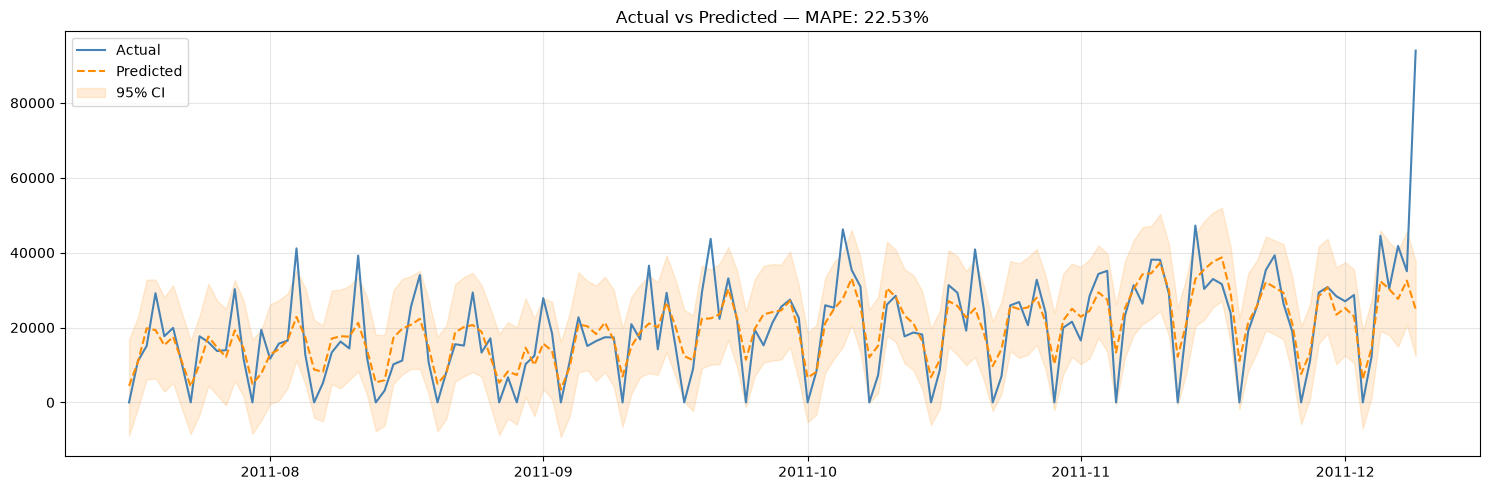

In [83]:
# ── CELL J: Plot ──
plt.figure(figsize=(15, 5))
plt.plot(evaluation_df["ds"], evaluation_df["y"],    label="Actual",    color="steelblue")
plt.plot(evaluation_df["ds"], evaluation_df["yhat"], label="Predicted", color="darkorange", linestyle="--")
plt.fill_between(evaluation_df["ds"],
    forecast["yhat_lower"], forecast["yhat_upper"],
    alpha=0.15, color="darkorange", label="95% CI")
plt.title(f"Actual vs Predicted — MAPE: {metrics['mape']:.2f}%")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

Final Prophet Model (Frozen)

Model:
Prophet

External Regressors:
✓ Invoice_Count
✓ SKU_Count
✓ Rolling_7_Day_Demand
✓ Is_Weekend

Hyperparameters

changepoint_prior_scale = 0.01

seasonality_prior_scale = 15

seasonality_mode = multiplicative

yearly_seasonality = True

weekly_seasonality = True

daily_seasonality = False

custom monthly seasonality
period = 30.5
fourier_order = 5

Final Performance

MAE  : 5534.49

RMSE : 8759.64

MAPE : 22.53%

Status:
Production Frozen

# RetailPulse Demand Forecasting

## Dataset Loading

## Data Cleaning

## Exploratory Data Analysis

## Time Series Preparation

## Trend Analysis

## Prophet Forecasting

## Forecast Evaluation

## Forecast Export

## Inventory Recommendations